# RAG Config Walkthrough

로컬 Jupyter 환경에서 RAG config를 선택해 실행하고, ingest/retrieve/chat/evaluate 결과를 확인하는 기본 노트북입니다.

상단 FLAG 변수로 실험 실행/건너뛰기를 제어합니다. 이미 ingest가 완료된 상태라면 `RUN_INGEST = False`로 두고 시각화와 평가만 다시 볼 수 있습니다.

## 1. 실험 기준

이 노트북은 코드를 직접 고치는 대신 config 파일을 선택해 RAG 실험을 실행하는 흐름을 보여줍니다.
처음에는 기준 config를 그대로 실행하고, 필요할 때만 다른 YAML로 바꿔 비교합니다.

- 기준 config: `configs/experiments/rag/rag_keyword.yaml` (로컬 smoke test)\n
- 로컬 비교 config: `configs/experiments/rag/rag_hybrid.yaml`, `rag_semantic.yaml`\n
- VM 실험 config: `configs/experiments/rag/rag_langchain.yaml` (/shared/data/raw_docs)\n
- 준실제 문서 검증 config: `configs/experiments/rag/rag_realistic_docs.yaml`
- 평가 질문: `data/rag_sample/eval_questions.csv`
- 주로 바꿔볼 옵션: `rag.splitter.chunk_size`, `rag.splitter.chunk_overlap`, `rag.retriever.method`, `rag.retriever.top_k`, `rag.answerer.provider`

비교 config는 처음부터 꼭 필요하지 않습니다. config 루트는 `CONFIG_ROOT = Path("configs/experiments/rag")`로 고정하고, `EXP_NAME`만 YAML 파일 이름에 맞춰 바꿉니다. 기준안이 없을 때는 `EXP_NAME = "rag_langchain"`으로 산출물 계약이 맞는지 먼저 확인합니다.

| `EXP_NAME` | config | 목적 |
| --- | --- | --- |
| `rag_keyword` | `rag_keyword.yaml` | 가장 먼저 돌리는 로컬 smoke test입니다. data/rag_sample로 동작합니다. |\n
| `rag_langchain` | `rag_langchain.yaml` | VM에서 실제 문서로 실험할 때 사용합니다. /shared/data/raw_docs를 읽습니다. |\n
| `rag_hybrid` | `rag_hybrid.yaml` | retriever 방식 비교가 필요할 때 쓰는 예시 config입니다. 처음부터 필수는 아닙니다. |
| `rag_realistic_docs` | `rag_realistic_docs.yaml` | DOCX/HWPX 준실제 문서에서 loader와 citation metadata가 깨지지 않는지 확인합니다. |

In [13]:
from pathlib import Path
import json
import os
import shlex
import sys
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    """현재 노트북 위치에서 프로젝트 루트 디렉터리를 찾습니다."""
    markers = ("AGENTS.md", "configs", "scripts", "src")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(
        "프로젝트 루트를 찾지 못했습니다. "
        "AGENTS.md, configs/, scripts/, src/가 있는 위치에서 실행해 주세요."
    )


PROJECT_ROOT = find_project_root(Path.cwd()).resolve()
os.chdir(PROJECT_ROOT)
PYTHON = shlex.quote(sys.executable)

from src.config import load_config

CONFIG_ROOT = Path("configs/experiments/rag")

# 기준안이 없을 때는 rag_keyword부터 실행합니다. 로컬에서 샘플 데이터로 동작합니다.
# VM에서는 EXP_NAME을 rag_langchain으로 바꿔 실제 문서를 실험합니다.
# 비교가 필요하면 EXP_NAME을 rag_hybrid 같은 config 파일 이름으로 바꿉니다.
EXP_NAME = "rag_keyword"
RAG_CONFIG = CONFIG_ROOT / f"{EXP_NAME}.yaml"
# QUESTION은 retrieve/chat 동작을 눈으로 확인하는 디버깅용 단일 질문입니다.
# 전체 평가는 config의 evaluation.questions_path CSV를 --evaluate로 실행합니다.
QUESTION = "예산은 얼마야?"


def config_output_dir(config_path: str | Path) -> Path:
    """config의 paths.output_dir을 읽어 실험 산출물 위치를 반환합니다."""
    return Path(load_config(config_path)["paths"]["output_dir"])


def config_questions_path(config_path: str | Path) -> Path:
    """config의 evaluation.questions_path를 읽어 평가 질문 위치를 반환합니다."""
    return Path(load_config(config_path)["evaluation"]["questions_path"])


OUTPUT_DIR = config_output_dir(RAG_CONFIG)
EVAL_QUESTIONS = config_questions_path(RAG_CONFIG)

print(f"project root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(f"experiment: {EXP_NAME}")
print(f"config: {RAG_CONFIG}")
print(f"output_dir: {OUTPUT_DIR}")


project root: /mnt/c/Users/Nighthom/Documents/프로젝트 킥오프
python: /home/n132/anaconda3/envs/codeit-ml-pipeline/bin/python
experiment: rag_keyword
config: configs/experiments/rag/rag_keyword.yaml
output_dir: experiments/rag_keyword


## 실험 실행 FLAG

아래 변수로 각 단계 실행 여부를 제어합니다.
이미 ingest가 완료된 상태에서 시각화만 다시 보려면 `RUN_INGEST = False`로 바꿉니다.

In [14]:
RUN_CHECK = True
RUN_INGEST = True        # False면 기존 chunks.csv 재사용하고 시각화만
RUN_RETRIEVE = True      # False면 단일 질문 검색 건너뜀
RUN_EVALUATE = True      # False면 기존 metrics.json 시각화만

## OpenAI API key 선택 설정

OpenAI 사용 여부는 노트북 변수가 아니라 config의 `rag.embedding.provider` 또는 `rag.answerer.provider`로 결정합니다.
기본 config는 local provider라 비용이 발생하지 않습니다. OpenAI provider config를 선택했을 때만 아래 환경변수가 필요합니다.

In [15]:
# OpenAI provider config를 사용할 때만 아래 두 줄의 주석을 해제합니다.
# import getpass
# os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

print("OPENAI_API_KEY 설정 여부:", bool(os.environ.get("OPENAI_API_KEY")))

OPENAI_API_KEY 설정 여부: False


In [16]:
def run(command: str) -> None:
    print(f"$ {command}")
    result = __import__("subprocess").run(command, shell=True, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"command failed: {command}")

def show_json(path: str | Path):
    path = Path(path)
    if not path.exists():
        print(f"missing: {path}")
        return {}
    return json.loads(path.read_text(encoding="utf-8"))

def show_csv(path: str | Path, n: int = 5):
    path = Path(path)
    if not path.exists():
        print(f"missing: {path}")
        return pd.DataFrame()
    return pd.read_csv(path).head(n)

def show_jsonl(path: str | Path, n: int = 3):
    path = Path(path)
    if not path.exists():
        print(f"missing: {path}")
        return []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return rows[:n]

def display_metrics(path: str | Path):
    metrics = show_json(path)
    if not metrics:
        return pd.DataFrame()
    rows = [{"metric": key, "value": value} for key, value in metrics.items()]
    return pd.DataFrame(rows)

def display_answers(path: str | Path, n: int = 5):
    rows = show_jsonl(path, n=n)
    summary = []
    for row in rows:
        citations = row.get("citations", [])
        citation_text = "; ".join(
            f"{item.get('source_path', '')}:{item.get('chunk_id', '')}"
            for item in citations
        )
        summary.append({
            "question": row.get("question"),
            "status": row.get("status"),
            "answer": row.get("answer"),
            "citations": citation_text,
        })
    return pd.DataFrame(summary)

def display_failure_tables(output_dir: str | Path, n: int = 5):
    output_dir = Path(output_dir)
    tables = {
        "bad_retrievals": output_dir / "bad_retrievals.csv",
        "unsupported_answers": output_dir / "unsupported_answers.csv",
        "failed_questions": output_dir / "failed_questions.csv",
    }
    for title, path in tables.items():
        print(f"## {title}")
        display(show_csv(path, n=n))

def display_artifact_check(output_dir: str | Path):
    output_dir = Path(output_dir)
    required = [
        "config.yaml", "parsed_documents.csv", "chunks.csv", "embeddings.jsonl",
        "retrieval_results.jsonl", "answers.jsonl", "evaluation_results.csv",
        "bad_retrievals.csv", "unsupported_answers.csv", "failed_questions.csv",
        "metrics.json", "run_status.json", "rag_ingest_checkpoint.json",
    ]
    rows = [{"artifact": name, "exists": (output_dir / name).exists()} for name in required]
    rows.append({"artifact": "failure.log", "exists": (output_dir / "failure.log").exists()})
    return pd.DataFrame(rows)

def plot_metric_bar(metrics_path: str | Path):
    metrics = show_json(metrics_path)
    if not metrics:
        print("metrics.json not found")
        return
    names = list(metrics.keys())
    values = list(metrics.values())
    colors = ["#4CAF50" if v >= 0.7 else "#FF9800" if v >= 0.4 else "#F44336" for v in values]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(names, values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title(f"RAG Metrics")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", ha="center", fontsize=10)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

def plot_failure_counts(output_dir: str | Path):
    output_dir = Path(output_dir)
    counts = {}
    for name in ["bad_retrievals", "unsupported_answers", "failed_questions"]:
        path = output_dir / f"{name}.csv"
        if path.exists():
            df = pd.read_csv(path)
            counts[name] = len(df)
        else:
            counts[name] = 0
    if sum(counts.values()) == 0:
        print("실패 케이스가 없습니다.")
        return
    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.bar(counts.keys(), counts.values(), color=["#FF9800", "#2196F3", "#F44336"])
    ax.set_ylabel("count")
    ax.set_title("Failure Case Breakdown")
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha="center")
    plt.tight_layout()
    plt.show()

def display_chunk_summary(output_dir: str | Path):
    path = Path(output_dir) / "chunks.csv"
    if not path.exists():
        print("chunks.csv not found")
        return
    df = pd.read_csv(path)
    print(f"총 chunk 수: {len(df)}")
    doc_counts = df["document_id"].value_counts()
    print(f"문서별 chunk 수:")
    for doc_id, count in doc_counts.items():
        print(f"  {doc_id}: {count}개")
    if "token_count" in df.columns:
        print(f"chunk 길이 - min: {df['token_count'].min()}, max: {df['token_count'].max()}, mean: {df['token_count'].mean():.0f}")
    return doc_counts

## 2. 입력 확인

원본 문서와 평가 질문 CSV가 준비되어 있는지 확인합니다.
여기서 파일이 없으면 pipeline 문제가 아니라 경로 또는 데이터 준비 문제일 가능성이 큽니다.

`QUESTION`은 단일 질문으로 retrieval/chat 흐름을 빠르게 보는 용도입니다. 실제 평가와 metric 계산은 `EVAL_QUESTIONS` CSV 전체를 대상으로 실행합니다.

`OUTPUT_DIR`과 `EVAL_QUESTIONS`는 config에서 읽어옵니다. 실험 이름을 바꿀 때는 경로 문자열을 여러 곳에서 직접 고치지 말고 위의 `CONFIG_ROOT`와 `EXP_NAME`을 먼저 확인합니다.

In [17]:
print(RAG_CONFIG, RAG_CONFIG.exists())
print(EVAL_QUESTIONS, EVAL_QUESTIONS.exists())
show_csv(EVAL_QUESTIONS)

configs/experiments/rag/rag_keyword.yaml True
data/rag_sample/eval_questions.csv True


,question,expected_answer,expected_chunk_ids
0,예산이 얼마야?,5천만 원,rfp_sample_chunk_0001
1,마감일은 언제야?,2026년 7월 10일,rfp_sample_chunk_0002
2,참가 자격은 뭐야?,최근 3년 이내 유사 사업 수행 경험,rfp_sample_chunk_0003


## 3. 실행 전 config 점검

`check_rag_pipeline.py`는 실제 산출물을 만들기 전에 config와 입력 경로를 검증합니다.
실패하면 먼저 YAML의 상대 경로가 프로젝트 루트 기준으로 맞는지 확인합니다.

In [18]:
if RUN_CHECK:
    run(f"{PYTHON} scripts/check_rag_pipeline.py --config {RAG_CONFIG} --project-root .")
else:
    print("RUN_CHECK=False: check 생략")

$ /home/n132/anaconda3/envs/codeit-ml-pipeline/bin/python scripts/check_rag_pipeline.py --config configs/experiments/rag/rag_keyword.yaml --project-root .
{'ok': True, 'errors': [], 'warnings': ["ignored files due to file type filter: ['eval_questions.csv']", 'output_dir already exists and may be overwritten: experiments/rag_keyword'], 'summary': {'config_path': 'configs/experiments/rag/rag_keyword.yaml', 'experiment': 'rag_keyword', 'raw_docs_dir': 'data/rag_sample', 'output_dir': 'experiments/rag_keyword', 'questions_path': 'data/rag_sample/eval_questions.csv', 'file_types': ['docx', 'hwp', 'hwpx', 'pdf', 'txt'], 'document_counts': {'txt': 1}, 'retriever_method': 'keyword', 'engine': 'local', 'chunk_size': 500, 'chunk_overlap': 80, 'checkpoint_enabled': True, 'checkpoint_resume': True, 'embedding_provider': 'local', 'embedding_model': 'hashing-char-ngram-v1', 'vector_store_type': 'memory', 'vector_store_path': None, 'artifact_run_id': None, 'artifact_on_existing': 'overwrite', 'reran

## 4. Ingest 실행

문서를 읽고 chunk와 embedding 산출물을 만듭니다.
이 단계의 핵심 산출물은 `parsed_documents.csv`, `chunks.csv`, `embeddings.jsonl`입니다.
chunk가 너무 짧거나 길면 `rag.splitter.chunk_size`와 `rag.splitter.chunk_overlap`을 조정합니다.

In [19]:
if RUN_INGEST:
    run(f"{PYTHON} scripts/run_rag_ingest.py --config {RAG_CONFIG} --project-root .")
else:
    print("RUN_INGEST=False: ingest 생략, 기존 chunks.csv 사용")

show_csv(OUTPUT_DIR / "chunks.csv")

$ /home/n132/anaconda3/envs/codeit-ml-pipeline/bin/python scripts/run_rag_ingest.py --config configs/experiments/rag/rag_keyword.yaml --project-root .
{'documents': 3, 'chunks': 3, 'embeddings': 3}



,chunk_id,document_id,source_path,page_start,page_end,section,text,token_count
0,rfp_sample_chunk_0001,rfp_sample,data/rag_sample/rfp_sample.txt,1,1,사업 개요,본 사업의 예산은 5천만 원입니다. 사업 목적은 RFP 문서를 빠르게 분석하는 AI...,15
1,rfp_sample_chunk_0002,rfp_sample,data/rag_sample/rfp_sample.txt,1,1,제출 일정,제안서 제출 마감일은 2026년 7월 10일입니다. 제출 시간은 오후 5시까지입니다.,10
2,rfp_sample_chunk_0003,rfp_sample,data/rag_sample/rfp_sample.txt,1,1,참가 자격,참가 자격은 최근 3년 이내 유사 사업 수행 경험을 보유한 업체입니다. 컨소시엄 참...,14


## 4-1. Chunk 통계 요약

문서별 chunk 수와 길이 분포를 확인합니다. 문서마다 chunk 수가 지나치게 차이나거나 chunk가 너무 짧으면 loader나 splitter 설정을 의심합니다.

In [20]:
display_chunk_summary(OUTPUT_DIR)

총 chunk 수: 3
문서별 chunk 수:
  rfp_sample: 3개
chunk 길이 - min: 10, max: 15, mean: 13


document_id
rfp_sample    3
Name: count, dtype: int64

## 5. 검색 결과 확인

질문 하나를 던져 어떤 chunk가 검색되는지 확인합니다.
답변 품질이 나쁘면 먼저 LLM보다 retrieval 결과가 맞는지 보는 것이 좋습니다.

In [21]:
if RUN_RETRIEVE:
    run(f"{PYTHON} scripts/run_rag_retrieve.py --config {RAG_CONFIG} --project-root . --question {shlex.quote(QUESTION)}")
else:
    print("RUN_RETRIEVE=False: retrieve 생략")

$ /home/n132/anaconda3/envs/codeit-ml-pipeline/bin/python scripts/run_rag_retrieve.py --config configs/experiments/rag/rag_keyword.yaml --project-root . --question '예산은 얼마야?'
{'question': '예산은 얼마야?', 'top_k': 3, 'retriever_method': 'keyword', 'retrieved_chunks': [{'rank': 1, 'score': 2.5, 'chunk_id': 'rfp_sample_chunk_0001', 'document_id': 'rfp_sample', 'source_path': 'data/rag_sample/rfp_sample.txt', 'page': '1', 'section': '사업 개요', 'text': '본 사업의 예산은 5천만 원입니다. 사업 목적은 RFP 문서를 빠르게 분석하는 AI 챗봇을 구축하는 것입니다.'}]}



## 6. 답변과 평가 실행

먼저 `QUESTION` 하나로 답변과 citation 모양을 확인합니다.
그 다음 `--evaluate`로 config의 `evaluation.questions_path`에 있는 평가 질문 CSV 전체를 실행합니다.

즉 단일 질문은 디버깅용이고, metric은 평가 CSV 전체 실행 결과를 기준으로 봅니다. 평가는 검색 성공 여부, 답변에 기대 답이 포함되는지, citation이 맞는지를 함께 봅니다.

In [22]:
if RUN_EVALUATE:
    run(f"{PYTHON} scripts/run_rag_chat.py --config {RAG_CONFIG} --project-root . --question {shlex.quote(QUESTION)}")
    run(f"{PYTHON} scripts/run_rag_chat.py --config {RAG_CONFIG} --project-root . --evaluate")
else:
    print("RUN_EVALUATE=False: evaluate 생략, 기존 metrics.json 시각화만")

$ /home/n132/anaconda3/envs/codeit-ml-pipeline/bin/python scripts/run_rag_chat.py --config configs/experiments/rag/rag_keyword.yaml --project-root . --question '예산은 얼마야?'
{'question': '예산은 얼마야?', 'answer': '본 사업의 예산은 5천만 원입니다.', 'citations': [{'chunk_id': 'rfp_sample_chunk_0001', 'document_id': 'rfp_sample', 'source_path': 'data/rag_sample/rfp_sample.txt', 'page': '1', 'section': '사업 개요'}], 'status': 'answered'}

$ /home/n132/anaconda3/envs/codeit-ml-pipeline/bin/python scripts/run_rag_chat.py --config configs/experiments/rag/rag_keyword.yaml --project-root . --evaluate
{'retrieval_hit_rate': 1.0, 'answer_contains_expected_rate': 1.0, 'citation_correct_rate': 1.0, 'not_found_rate': 0.0}



## 7. Metric과 실패 사례 확인

`metrics.json`은 표로 요약해서 봅니다.
점수가 낮을 때는 아래 실패 CSV를 보고 retrieval 문제인지, answerer 문제인지 분리해서 판단합니다.

In [23]:
display_metrics(OUTPUT_DIR / "metrics.json")

,metric,value
0,retrieval_hit_rate,1.0
1,answer_contains_expected_rate,1.0
2,citation_correct_rate,1.0
3,not_found_rate,0.0


In [24]:
display_failure_tables(OUTPUT_DIR)

## bad_retrievals


,question,expected_answer,expected_chunk_ids,retrieved_chunk_ids,citation_chunk_ids,answer,retrieval_hit,answer_contains_expected,citation_correct,status


## unsupported_answers


,question,expected_answer,expected_chunk_ids,retrieved_chunk_ids,citation_chunk_ids,answer,retrieval_hit,answer_contains_expected,citation_correct,status


## failed_questions


,question,expected_answer,expected_chunk_ids,retrieved_chunk_ids,citation_chunk_ids,answer,retrieval_hit,answer_contains_expected,citation_correct,status


## 7-1. Metric 시각화

bar chart로 metric을 한눈에 비교합니다. 초록색(0.7+), 주황색(0.4~0.7), 빨간색(0.4 미만)으로 구분합니다.

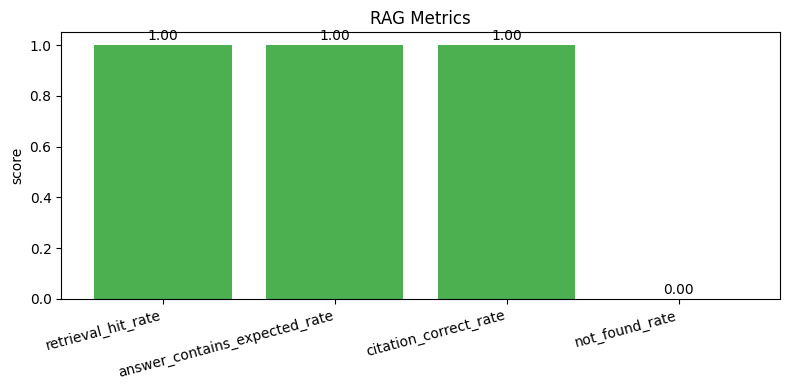

In [25]:
plot_metric_bar(OUTPUT_DIR / "metrics.json")

In [26]:
plot_failure_counts(OUTPUT_DIR)

실패 케이스가 없습니다.


## 8. 답변과 citation 확인

답변만 보면 그럴듯해 보여도 근거가 틀릴 수 있습니다.
여기서는 질문, 답변, 상태, citation을 한 표로 보고 답변이 실제 검색 근거를 따르는지 확인합니다.

In [27]:
display_answers(OUTPUT_DIR / "answers.jsonl")

,question,status,answer,citations
0,예산이 얼마야?,answered,본 사업의 예산은 5천만 원입니다.,data/rag_sample/rfp_sample.txt:rfp_sample_chun...
1,마감일은 언제야?,answered,제안서 제출 마감일은 2026년 7월 10일입니다.,data/rag_sample/rfp_sample.txt:rfp_sample_chun...
2,참가 자격은 뭐야?,answered,참가 자격은 최근 3년 이내 유사 사업 수행 경험을 보유한 업체입니다.,data/rag_sample/rfp_sample.txt:rfp_sample_chun...
3,예산은 얼마야?,answered,본 사업의 예산은 5천만 원입니다.,data/rag_sample/rfp_sample.txt:rfp_sample_chun...
4,예산이 얼마야?,answered,본 사업의 예산은 5천만 원입니다.,data/rag_sample/rfp_sample.txt:rfp_sample_chun...


## 9. 산출물 점검 및 다음 실험

실험 산출물이 모두 생성되었는지 artifact check로 확인합니다.

이 노트북은 `EXP_NAME`으로 선택한 config 하나를 끝까지 실행하는 흐름만 다룹니다.
다른 retriever나 문서 형식을 비교하려면 새 config를 만들거나 `EXP_NAME`을 다른 config 파일명으로 바꾼 뒤, FLAG를 조정해 이 노트북을 다시 실행합니다.

비교 리포트나 DOCX/HWPX 준실제 문서 리허설은 별도 노트북이나 별도 Issue에서 다룹니다.

In [28]:
display_artifact_check(OUTPUT_DIR)

,artifact,exists
0,config.yaml,True
1,parsed_documents.csv,True
2,chunks.csv,True
3,embeddings.jsonl,True
4,retrieval_results.jsonl,True
5,answers.jsonl,True
6,evaluation_results.csv,True
7,bad_retrievals.csv,True
8,unsupported_answers.csv,True
9,failed_questions.csv,True
